<a href="https://colab.research.google.com/github/viniciushodos/Projetos-da-disciplina-de-Cincia-de-Dados-e-IA/blob/main/exemplo_pratico_Apriori.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para a utilização da biblioteca é necessário o download dela que está no link abaixo

[texto do link](https://www.kaggle.com/datasets/hemanthkumar05/**market**-basket-optimization?resource=download)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (15, 10)
!pip -qq install apyori
import apyori

from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
  mercado = pd.read_csv(fn)


mercado.head(10)



Saving Market_Basket_Optimisation.xls to Market_Basket_Optimisation (10).xls
User uploaded file "Market_Basket_Optimisation (10).xls" with length 302908 bytes


,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
0,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,low fat yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,whole wheat pasta,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,soup,light cream,shallot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,frozen vegetables,spaghetti,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,french fries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,eggs,pet food,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
len(mercado)

7500

In [ ]:
for index in mercado.columns:
  mercado[index] = mercado[index].astype(str).str.strip()

In [ ]:
itens = mercado.melt()['value'].dropna().sort_values()
print(f'Existem {itens.nunique()} produtos distintos:\n', itens.unique())

Existem 120 produtos distintos:
 ['almonds' 'antioxydant juice' 'asparagus' 'avocado' 'babies food' 'bacon'
 'barbecue sauce' 'black tea' 'blueberries' 'body spray' 'bramble'
 'brownies' 'bug spray' 'burger sauce' 'burgers' 'butter' 'cake'
 'candy bars' 'carrots' 'cauliflower' 'cereals' 'champagne' 'chicken'
 'chili' 'chocolate' 'chocolate bread' 'chutney' 'cider'
 'clothes accessories' 'cookies' 'cooking oil' 'corn' 'cottage cheese'
 'cream' 'dessert wine' 'eggplant' 'eggs' 'energy bar' 'energy drink'
 'escalope' 'extra dark chocolate' 'flax seed' 'french fries'
 'french wine' 'fresh bread' 'fresh tuna' 'fromage blanc'
 'frozen smoothie' 'frozen vegetables' 'gluten free bar' 'grated cheese'
 'green beans' 'green grapes' 'green tea' 'ground beef' 'gums' 'ham'
 'hand protein bar' 'herb & pepper' 'honey' 'hot dogs' 'ketchup'
 'light cream' 'light mayo' 'low fat yogurt' 'magazines' 'mashed potato'
 'mayonnaise' 'meatballs' 'melons' 'milk' 'mineral water' 'mint'
 'mint green tea' 'muffins'

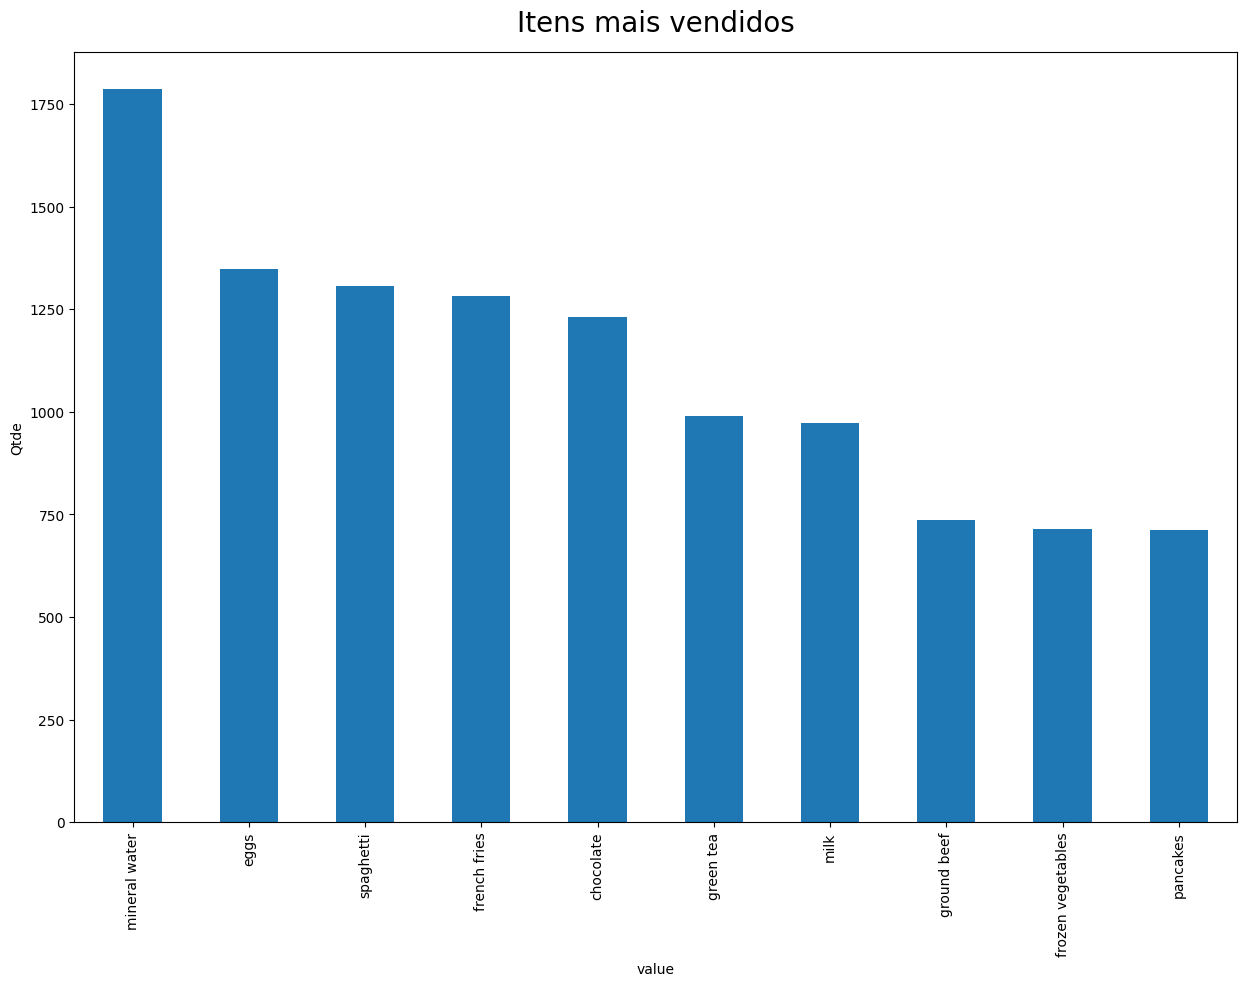

In [ ]:
qtde_itens = itens.value_counts()

# Filtrando para remover o 'nan'
qtde_itens = qtde_itens.drop('nan', errors='ignore')

barra = qtde_itens.nlargest(10).plot(kind='bar')
barra.set_title('Itens mais vendidos', size=20, weight=500, pad=15)
barra.set_ylabel('Qtde')
plt.show()

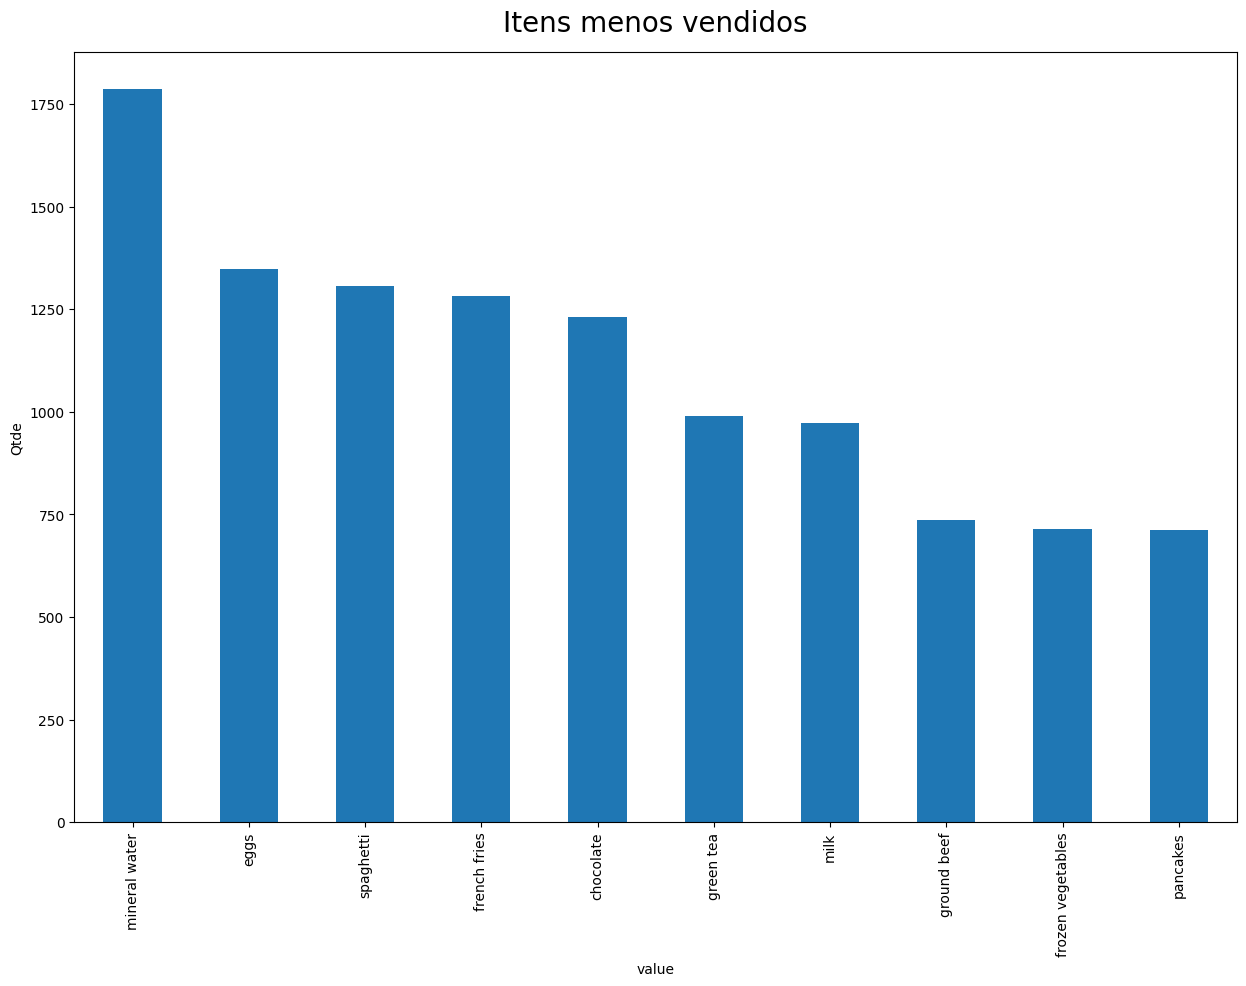

In [ ]:

barra = qtde_itens.nlargest(10).plot(kind='bar')
barra.set_title('Itens menos vendidos', size=20, weight=500, pad=15)
barra.set_ylabel('Qtde')
plt.show()

In [ ]:
# Em vez de sum(), verificamos quais células não contêm a string 'nan'
# Isso evita o erro de somar texto com números
qtde_por_cesta = (mercado != 'nan').sum(axis=1)

# Criamos as cestas filtrando a string 'nan' e garantindo mais de 1 item
cestas = [set(item for item in linha if item != 'nan') for _, linha in mercado[qtde_por_cesta > 1].iterrows()]

display(cestas[:5])

[{'burgers', 'eggs', 'meatballs'},
 {'avocado', 'turkey'},
 {'energy bar', 'green tea', 'milk', 'mineral water', 'whole wheat rice'},
 {'french fries', 'whole wheat pasta'},
 {'light cream', 'shallot', 'soup'}]

In [ ]:
len(cestas)

5746

In [ ]:
minsup = 0.04
minconf = 0.3

regras_associacao = apyori.apriori(cestas, min_support=minsup, min_confidence=minconf)

for regra in regras_associacao:
  itens = list(regra.items)
  print(
      f'{itens[:-1]} --> [{itens[-1]}] Suporte {regra.support:.3f}'
      f' Confiança: {regra.ordered_statistics[0].confidence:.3f}'
      )

['mineral water'] --> [chocolate] Suporte 0.069 Confiança: 0.342
['mineral water'] --> [eggs] Suporte 0.066 Confiança: 0.304
['frozen vegetables'] --> [mineral water] Suporte 0.047 Confiança: 0.385
['mineral water'] --> [ground beef] Suporte 0.053 Confiança: 0.429
['spaghetti'] --> [ground beef] Suporte 0.051 Confiança: 0.411
['milk'] --> [mineral water] Suporte 0.063 Confiança: 0.383
['mineral water'] --> [pancakes] Suporte 0.044 Confiança: 0.375
['mineral water'] --> [spaghetti] Suporte 0.078 Confiança: 0.357
